<a href="https://colab.research.google.com/github/vidaltiburciodominguez-boop/Retail-Maintenance-Logistics-Budget-Audit-Acapulco-Iguala-/blob/main/Retail_Maintenance_Logistics_%26_Budget_Audit_(Acapulco_%26_Iguala).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.- Carga de la base de datos


Descripción de Columnas del Dataset
ID_Gasto (Texto / object): Identificador único del comprobante o ticket registrado (ej. EXP-GUE-001). Sirve como llave primaria y garantiza que no existan duplicados.

ID_Solicitud_WO (Texto / object): Identificador de la orden de trabajo (Work Order) asignada por Coppel. Vincula los gastos a las 10 solicitudes de servicio únicas del proyecto.

Sede_Ubicacion (Texto / object): Inmueble donde se realizó el trabajo. Clasifica las 8 sedes atendidas entre Acapulco (Bahía, Renacimiento, Pie de la Cuesta, Cobranza 1 y 2, Estacionamiento, CEDIS 1) e Iguala (Tienda Tamarindos).

Descripcion_Trabajo (Texto / object): Tipo de mantenimiento o remodelación ejecutada en el sitio (ej. resanes, cambio de loseta, pintura en tablaroca, repetidores HDMI, compactación de gravilla).

Fecha (Texto $\rightarrow$ datetime): Fecha del gasto dentro del periodo de ejecución del proyecto (01 de abril al 31 de mayo de 2026).

Categoria_Gasto (Texto / object): Clasificación del tipo de erogación en 4 rubros principales: Logística, Viáticos, Materiales de Stock (CDMX) y Materiales de Emergencia (Local).

Proveedor (Texto / object): Entidad a la que se realizó el pago (CAPUFE, Pemex, Hotel, Home Depot Acapulco, Ferreterías locales o Proveedor Central).

Presupuesto_Asignado_MXN (Numérico / float64): Monto en pesos mexicanos proyectado originalmente para ese concepto dentro del presupuesto global de $250,000.00 MXN.

Gasto_Real_MXN (Numérico / float64): Monto final facturado o pagado en ticket. Permite evaluar las desviaciones financieras respecto a lo planeado.

2.- Analisis explotatorio


In [32]:
import pandas as pd

# 1. Carga del archivo original
df_guerrero = pd.read_csv('proyecto_guerrero_coppel.csv')

# --- PASO 1: ESTRUCTURA Y MUESTRA ---
print("=== 1. DIMENSIÓN DEL DATASET ===")
print(f"Filas: {df_guerrero.shape[0]} | Columnas: {df_guerrero.shape[1]}\n")

print("=== VISTA PREVIA (Primeras 5 filas) ===")
print(df_guerrero.head(), "\n")

# --- PASO 2: TIPOS DE DATOS DETECTADOS ---
print("=== 2. TIPOS DE DATOS ===")
print(df_guerrero.dtypes, "\n")

# --- PASO 3: DETECCIÓN DE VALORES NULOS Y DUPLICADOS ---
print("=== 3. CALIDAD DE DATOS (NULOS Y DUPLICADOS) ===")
print(f"Total de registros nulos:\n{df_guerrero.isnull().sum()}\n")
print(f"Filas duplicadas: {df_guerrero.duplicated().sum()}")
print(f"IDs de gasto duplicados: {df_guerrero['ID_Gasto'].duplicated().sum()}\n")

# --- PASO 4: CARDINALIDAD Y COBERTURA POR SEDE Y CATEGORÍA ---
print("=== 4. COBERTURA OPERATIVA Y CATEGORÍAS ===")
print("\nRegistros de gasto por Sede:")
print(df_guerrero['Sede_Ubicacion'].value_counts())

print("\nRegistros por Categoría de Gasto:")
print(df_guerrero['Categoria_Gasto'].value_counts())

print("\nCantidad de Solicitudes de Trabajo (WO) únicas:", df_guerrero['ID_Solicitud_WO'].nunique())

=== 1. DIMENSIÓN DEL DATASET ===
Filas: 135 | Columnas: 9

=== VISTA PREVIA (Primeras 5 filas) ===
      ID_Gasto ID_Solicitud_WO                      Sede_Ubicacion  \
0  EXP-GUE-001   WO-COP-GUE-07  Acapulco - Tienda Pie de la Cuesta   
1  EXP-GUE-002   WO-COP-GUE-09             Acapulco - Tienda Bahía   
2  EXP-GUE-003   WO-COP-GUE-04      Acapulco - Tienda Renacimiento   
3  EXP-GUE-004   WO-COP-GUE-10          Acapulco - Estacionamiento   
4  EXP-GUE-005   WO-COP-GUE-08          Acapulco - Estacionamiento   

           Descripcion_Trabajo       Fecha  \
0           Cambio de lámparas  2026-04-01   
1             Repetidores HDMI  2026-04-01   
2       Remodelación Tablaroca  2026-04-01   
3           Compactar gravilla  2026-04-02   
4  Lámparas de estacionamiento  2026-04-02   

                             Categoria_Gasto               Proveedor  \
0                Logística (Peajes/Gasolina)                   Pemex   
1           Viáticos (Hospedaje y Alimentos)          Hotel

In [33]:
df_guerrero['Fecha'] = pd.to_datetime(df_guerrero['Fecha'])
print(df_guerrero.dtypes)

ID_Gasto                            object
ID_Solicitud_WO                     object
Sede_Ubicacion                      object
Descripcion_Trabajo                 object
Fecha                       datetime64[ns]
Categoria_Gasto                     object
Proveedor                           object
Presupuesto_Asignado_MXN           float64
Gasto_Real_MXN                     float64
dtype: object


Ahora que la columna `Fecha` está en formato datetime, podemos extraer características adicionales basadas en el tiempo, como el mes, el día de la semana o la semana del año, lo que puede ser útil para un análisis posterior.

## Ajuste de Categorías: Compactar "Instalaciones Eléctricas"

Para una mejor consolidación y análisis, compactaremos las diferentes descripciones de trabajo relacionadas con instalaciones eléctricas en una única categoría: `Instalaciones eléctricas`. Esto incluye los trabajos de 'Instalaciones eléctricas (Contactos)', 'Cambio de lámparas' y 'Lámparas de estacionamiento'.

In [34]:
# Definir las categorías a compactar y el nuevo nombre
old_electrical_categories = [
    'Instalaciones eléctricas (Contactos)',
    'Cambio de lámparas',
    'Lámparas de estacionamiento'
]
new_electrical_category = 'Instalaciones eléctricas'

# Realizar el reemplazo en la columna 'Descripcion_Trabajo'
df_guerrero['Descripcion_Trabajo'] = df_guerrero['Descripcion_Trabajo'].replace(
    old_electrical_categories,
    new_electrical_category
)

# Verificar los valores únicos de la columna 'Descripcion_Trabajo' después de la compactación
print("\n--- Conteo de valores después de la compactación de 'Descripcion_Trabajo' ---")
display(df_guerrero['Descripcion_Trabajo'].value_counts())

print("\n--- Primeras 5 filas del DataFrame con la categoría actualizada ---")
display(df_guerrero.head())


--- Conteo de valores después de la compactación de 'Descripcion_Trabajo' ---


,count
Descripcion_Trabajo,
Instalaciones eléctricas,44
Pintura muros tablaroca,17
Resanes,15
Remodelación Tablaroca,12
Repetidores HDMI,11
Cambio de loseta,11
Compactar gravilla,10
Cambio de chapas,8
Plomería / Resanes,7



--- Primeras 5 filas del DataFrame con la categoría actualizada ---


,ID_Gasto,ID_Solicitud_WO,Sede_Ubicacion,Descripcion_Trabajo,Fecha,Categoria_Gasto,Proveedor,Presupuesto_Asignado_MXN,Gasto_Real_MXN
0,EXP-GUE-001,WO-COP-GUE-07,Acapulco - Tienda Pie de la Cuesta,Instalaciones eléctricas,2026-04-01,Logística (Peajes/Gasolina),Pemex,378.63,390.76
1,EXP-GUE-002,WO-COP-GUE-09,Acapulco - Tienda Bahía,Repetidores HDMI,2026-04-01,Viáticos (Hospedaje y Alimentos),Hotel Acapulco,414.52,441.19
2,EXP-GUE-003,WO-COP-GUE-04,Acapulco - Tienda Renacimiento,Remodelación Tablaroca,2026-04-01,Materiales de Emergencia (Local Guerrero),Home Depot Acapulco,1626.22,2030.84
3,EXP-GUE-004,WO-COP-GUE-10,Acapulco - Estacionamiento,Compactar gravilla,2026-04-02,Materiales de Stock (Base CDMX),Proveedor Central CDMX,5068.40,5054.79
4,EXP-GUE-005,WO-COP-GUE-08,Acapulco - Estacionamiento,Instalaciones eléctricas,2026-04-02,Materiales de Emergencia (Local Guerrero),Home Depot Acapulco,2441.89,3024.32


## Preguntas Clave de Negocio

1.  **Desviación Presupuestaria:** ¿Cuáles son las categorías de gasto y las sedes con mayor desviación entre el presupuesto asignado y el gasto real?
2.  **Eficiencia Operativa:** ¿Existen sedes o tipos de trabajo que son consistentemente más eficientes o ineficientes en la gestión de sus presupuestos?
3.  **Compras de Emergencia:** ¿Cuál es el impacto financiero de las compras de emergencia locales en comparación con los materiales de stock centralizados? ¿Podemos reducir estos sobrecostos?
4.  **Tendencias Temporales:** ¿Se observan patrones estacionales o tendencias en los gastos a lo largo del tiempo (mensual, semanal, diario)?
5.  **Optimización de Logística y Viáticos:** ¿Cómo podemos optimizar los gastos de logística y viáticos, que representan una parte significativa del presupuesto, sin comprometer la operación?

## Respuesta a la Pregunta 1: Desviación Presupuestaria

Para responder a esta pregunta, calcularemos la desviación (Gasto Real - Presupuesto Asignado) y el porcentaje de desviación (`(Gasto Real - Presupuesto) / Presupuesto * 100`). Luego, analizaremos estos valores agrupándolos por `Categoria_Gasto` y `Sede_Ubicacion` para identificar las áreas con mayores diferencias.


--- Desviación Total y Porcentual por Categoría de Gasto ---


,Total_Presupuesto,Total_Gasto_Real,Desviacion_Total,Desviacion_Promedio_Porcentual
Categoria_Gasto,,,,
Materiales de Emergencia (Local Guerrero),"$31,703.49","$39,020.79","$7,317.30",23.05%
Viáticos (Hospedaje y Alimentos),"$24,782.91","$26,117.70","$1,334.79",5.46%
Logística (Peajes/Gasolina),"$22,120.24","$22,656.25",$536.01,2.52%
Materiales de Stock (Base CDMX),"$171,393.34","$171,809.55",$416.21,0.21%



--- Desviación Total y Porcentual por Sede/Ubicación ---


,Total_Presupuesto,Total_Gasto_Real,Desviacion_Total,Desviacion_Promedio_Porcentual
Sede_Ubicacion,,,,
Acapulco - Tienda Renacimiento,"$38,709.23","$41,420.80","$2,711.57",8.36%
Acapulco - Tienda Bahía,"$53,623.60","$55,155.64","$1,532.04",4.45%
Acapulco - Oficina Cobranza 2,"$36,631.11","$38,009.13","$1,378.02",5.40%
Acapulco - CEDIS 1,"$30,038.59","$30,983.95",$945.36,4.60%
Acapulco - Estacionamiento,"$33,350.38","$34,209.42",$859.04,3.12%
Acapulco - Tienda Pie de la Cuesta,"$25,272.62","$26,104.00",$831.38,4.64%
Acapulco - Oficina Cobranza 1,"$16,270.43","$17,007.71",$737.28,6.64%
Iguala - Tienda Tamarindos,"$16,104.02","$16,713.64",$609.62,5.42%


/tmp/ipykernel_1903/4045125810.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=deviacion_por_categoria.index, y=deviacion_por_categoria['Desviacion_Promedio_Porcentual'], palette='coolwarm')


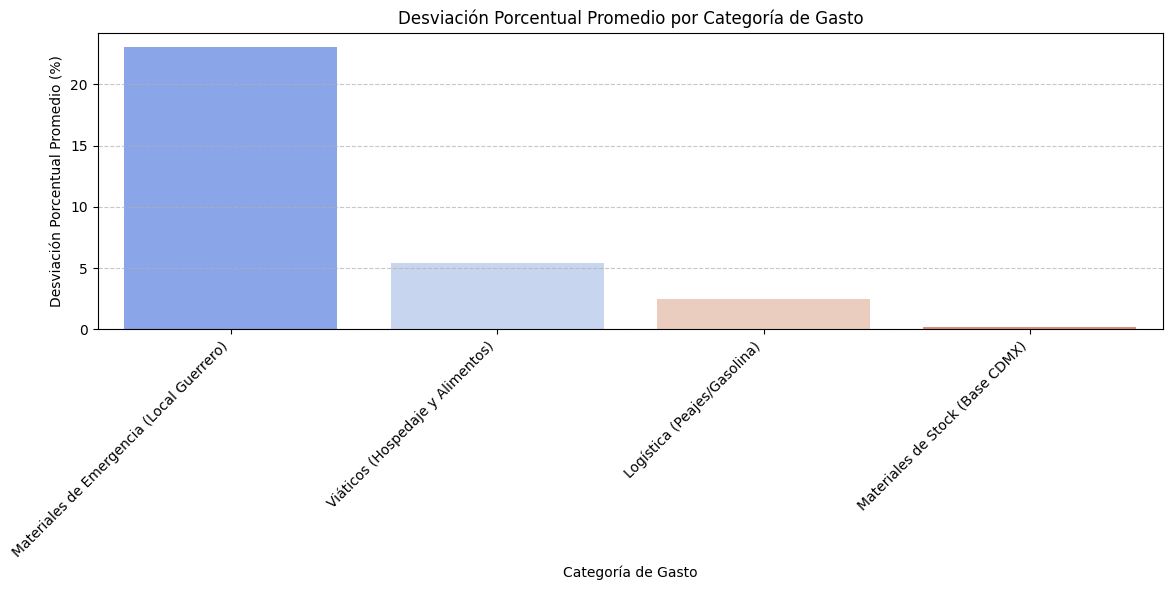

/tmp/ipykernel_1903/4045125810.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=deviacion_por_sede.index, y=deviacion_por_sede['Desviacion_Promedio_Porcentual'], palette='viridis')


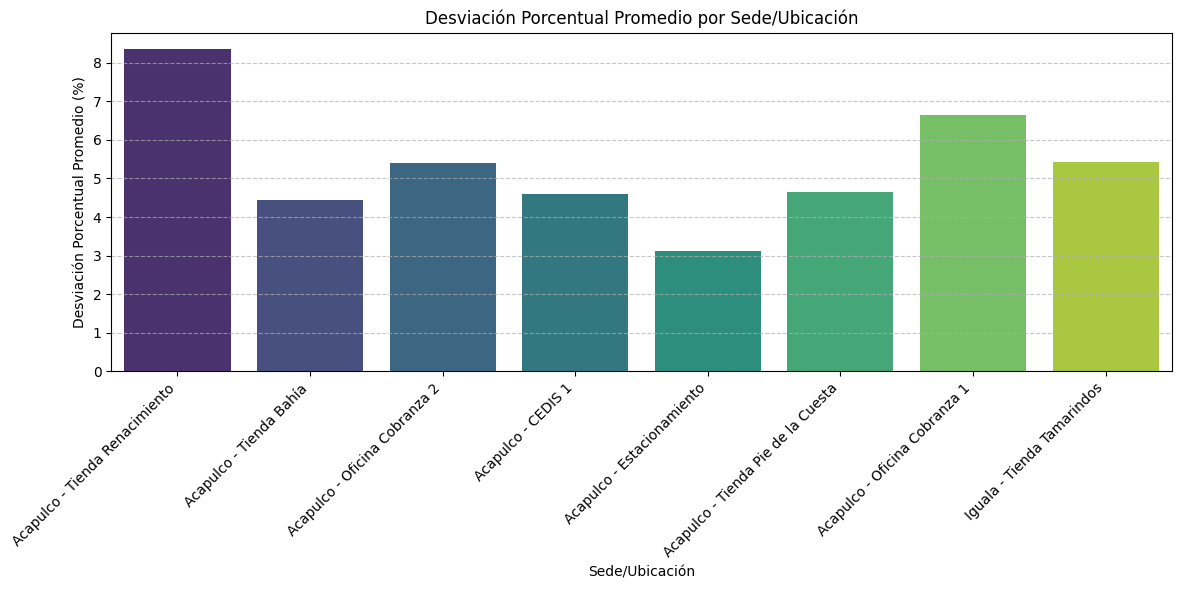

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la desviación absoluta y porcentual
df_guerrero['Desviacion_MXN'] = df_guerrero['Gasto_Real_MXN'] - df_guerrero['Presupuesto_Asignado_MXN']
df_guerrero['Desviacion_Porcentual'] = (df_guerrero['Desviacion_MXN'] / df_guerrero['Presupuesto_Asignado_MXN']) * 100

# Agrupar por Categoría de Gasto y calcular las desviaciones medias
deviacion_por_categoria = df_guerrero.groupby('Categoria_Gasto').agg(
    Total_Presupuesto=('Presupuesto_Asignado_MXN', 'sum'),
    Total_Gasto_Real=('Gasto_Real_MXN', 'sum'),
    Desviacion_Total=('Desviacion_MXN', 'sum'),
    Desviacion_Promedio_Porcentual=('Desviacion_Porcentual', 'mean')
).sort_values(by='Desviacion_Total', ascending=False)

print("\n--- Desviación Total y Porcentual por Categoría de Gasto ---")
display(deviacion_por_categoria.style.format({
    'Total_Presupuesto': '${:,.2f}',
    'Total_Gasto_Real': '${:,.2f}',
    'Desviacion_Total': '${:,.2f}',
    'Desviacion_Promedio_Porcentual': '{:,.2f}%'
}))

# Agrupar por Sede y calcular las desviaciones medias
deviacion_por_sede = df_guerrero.groupby('Sede_Ubicacion').agg(
    Total_Presupuesto=('Presupuesto_Asignado_MXN', 'sum'),
    Total_Gasto_Real=('Gasto_Real_MXN', 'sum'),
    Desviacion_Total=('Desviacion_MXN', 'sum'),
    Desviacion_Promedio_Porcentual=('Desviacion_Porcentual', 'mean')
).sort_values(by='Desviacion_Total', ascending=False)

print("\n--- Desviación Total y Porcentual por Sede/Ubicación ---")
display(deviacion_por_sede.style.format({
    'Total_Presupuesto': '${:,.2f}',
    'Total_Gasto_Real': '${:,.2f}',
    'Desviacion_Total': '${:,.2f}',
    'Desviacion_Promedio_Porcentual': '{:,.2f}%'
}))

# Visualización de la Desviación Porcentual Promedio por Categoría de Gasto
fig1_cat = plt.figure(figsize=(12, 6))
sns.barplot(x=deviacion_por_categoria.index, y=deviacion_por_categoria['Desviacion_Promedio_Porcentual'], palette='coolwarm')
plt.title('Desviación Porcentual Promedio por Categoría de Gasto')
plt.xlabel('Categoría de Gasto')
plt.ylabel('Desviación Porcentual Promedio (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualización de la Desviación Porcentual Promedio por Sede/Ubicación
fig1_sede = plt.figure(figsize=(12, 6))
sns.barplot(x=deviacion_por_sede.index, y=deviacion_por_sede['Desviacion_Promedio_Porcentual'], palette='viridis')
plt.title('Desviación Porcentual Promedio por Sede/Ubicación')
plt.xlabel('Sede/Ubicación')
plt.ylabel('Desviación Porcentual Promedio (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análisis de Desviación Presupuestaria:

**Por Categoría de Gasto:**

*   La categoría `Materiales de Emergencia (Local Guerrero)` muestra la mayor desviación total positiva, indicando un gasto real significativamente superior al presupuesto. Esto se refleja también en un alto `Desviacion_Promedio_Porcentual` del 23.05%, lo que sugiere que las compras de emergencia locales están generando sobrecostos importantes.
*   `Viáticos (Hospedaje y Alimentos)` y `Logística (Peajes/Gasolina)` también presentan desviaciones positivas, aunque en menor medida, con porcentajes promedio de sobrecosto del 5.46% y 2.52% respectivamente.
*   `Materiales de Stock (Base CDMX)` muestra una ligera desviación positiva promedio del 0.21%, lo que indica un buen control, aunque no se logra un ahorro consistente.

**Por Sede/Ubicación:**

*   `Acapulco - Tienda Renacimiento` y `Acapulco - Tienda Bahía` son las sedes con las mayores desviaciones totales en MXN, lo que sugiere que en estas ubicaciones se incurrió en gastos reales muy por encima de lo planificado.
*   `Acapulco - Tienda Renacimiento` tiene la `Desviacion_Promedio_Porcentual` más alta con un 8.36%, lo que la convierte en la sede con mayor sobrecosto relativo.
*   `Acapulco - Oficina Cobranza 1` y `Iguala - Tienda Tamarindos` también muestran desviaciones porcentuales promedio considerables.

**Conclusión de la Pregunta 1:**

Las **compras de emergencia locales** (`Materiales de Emergencia (Local Guerrero)`) son el principal factor de sobrecosto en el proyecto. Las sedes de **Acapulco - Tienda Renacimiento** y **Acapulco - Tienda Bahía** son las que presentan mayores problemas de ajuste presupuestario, probablemente debido a una mayor incidencia o magnitud de estos gastos de emergencia o a una planificación inicial menos precisa.

## Respuesta a la Pregunta 2: Eficiencia Operativa por Sede y Tipo de Trabajo

Esta pregunta se relaciona directamente con la anterior, profundizando en qué sedes y tipos de trabajo son consistentemente más eficientes o ineficientes. Analizaremos la desviación porcentual promedio para identificar estos patrones.


--- Eficiencia (Desviación Porcentual Promedio) por Sede ---


,Desviacion_Porcentual
Sede_Ubicacion,
Acapulco - Tienda Renacimiento,8.36%
Acapulco - Oficina Cobranza 1,6.64%
Iguala - Tienda Tamarindos,5.42%
Acapulco - Oficina Cobranza 2,5.40%
Acapulco - Tienda Pie de la Cuesta,4.64%
Acapulco - CEDIS 1,4.60%
Acapulco - Tienda Bahía,4.45%
Acapulco - Estacionamiento,3.12%


/tmp/ipykernel_1903/2091485889.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eficiencia_por_sede.index, y=eficiencia_por_sede.values, palette='viridis')


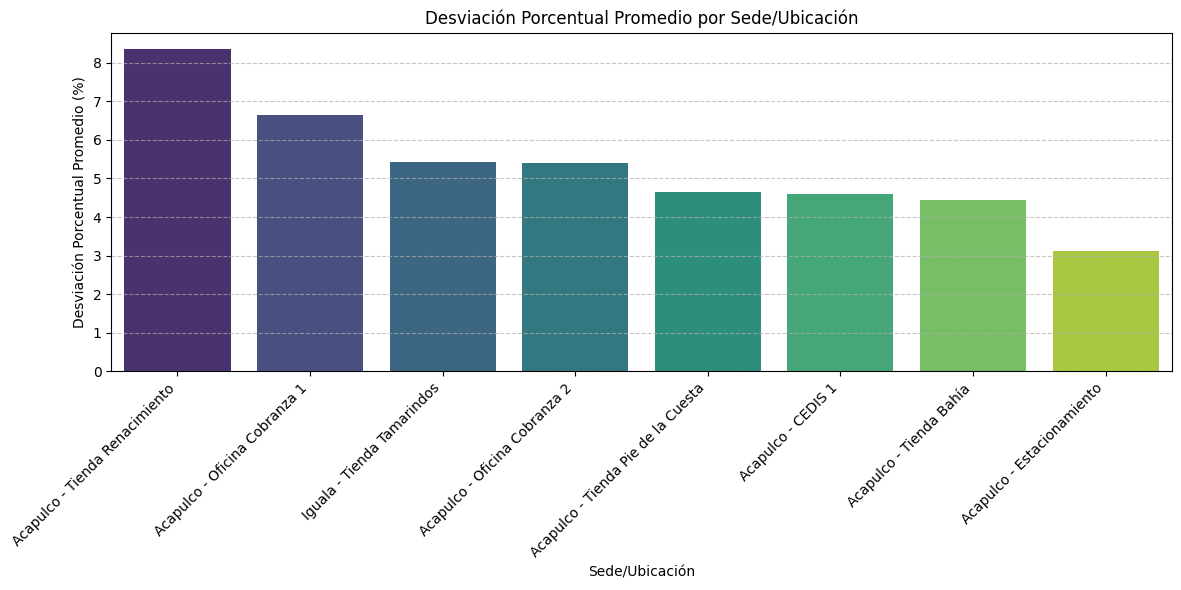


--- Eficiencia (Desviación Porcentual Promedio) por Tipo de Trabajo ---


,Desviacion_Porcentual
Descripcion_Trabajo,
Remodelación Tablaroca,8.96%
Resanes,8.70%
Pintura muros tablaroca,8.25%
Repetidores HDMI,4.85%
Instalaciones eléctricas,4.11%
Cambio de chapas,3.72%
Plomería / Resanes,3.57%
Compactar gravilla,2.18%
Cambio de loseta,2.01%


/tmp/ipykernel_1903/2091485889.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eficiencia_por_trabajo.head(10).index, y=eficiencia_por_trabajo.head(10).values, palette='magma')


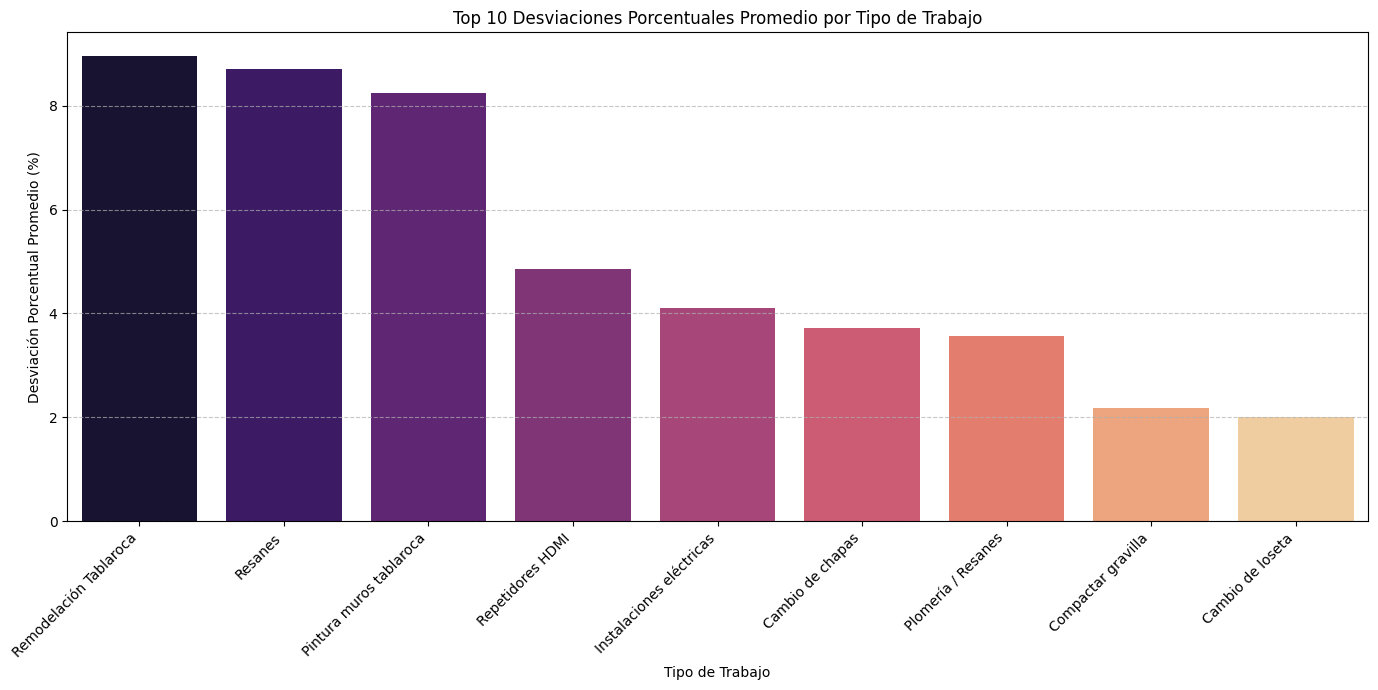

In [43]:
# Analizar la desviación porcentual promedio por Sede
eficiencia_por_sede = df_guerrero.groupby('Sede_Ubicacion')['Desviacion_Porcentual'].mean().sort_values(ascending=False)

print("\n--- Eficiencia (Desviación Porcentual Promedio) por Sede ---")
display(eficiencia_por_sede.apply(lambda x: f'{x:,.2f}%'))

# Visualización de la eficiencia por Sede
fig2_sede = plt.figure(figsize=(12, 6))
sns.barplot(x=eficiencia_por_sede.index, y=eficiencia_por_sede.values, palette='viridis')
plt.title('Desviación Porcentual Promedio por Sede/Ubicación')
plt.xlabel('Sede/Ubicación')
plt.ylabel('Desviación Porcentual Promedio (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Analizar la desviación porcentual promedio por Descripción de Trabajo
eficiencia_por_trabajo = df_guerrero.groupby('Descripcion_Trabajo')['Desviacion_Porcentual'].mean().sort_values(ascending=False)

print("\n--- Eficiencia (Desviación Porcentual Promedio) por Tipo de Trabajo ---")
display(eficiencia_por_trabajo.apply(lambda x: f'{x:,.2f}%'))

# Visualización de la eficiencia por Descripción de Trabajo (Top 10 para claridad)
fig2_trabajo = plt.figure(figsize=(14, 7))
sns.barplot(x=eficiencia_por_trabajo.head(10).index, y=eficiencia_por_trabajo.head(10).values, palette='magma')
plt.title('Top 10 Desviaciones Porcentuales Promedio por Tipo de Trabajo')
plt.xlabel('Tipo de Trabajo')
plt.ylabel('Desviación Porcentual Promedio (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análisis de Eficiencia Operativa:

**Por Sede/Ubicación:**

*   **Menos Eficientes (Mayor sobrecosto promedio):** `Acapulco - Tienda Renacimiento` (8.36%), `Acapulco - Oficina Cobranza 1` (6.64%) y `Iguala - Tienda Tamarindos` (5.42%) son las sedes con la desviación porcentual promedio más alta, lo que indica que sus gastos tienden a superar el presupuesto de forma más consistente.
*   **Más Eficientes (Menor sobrecosto promedio o incluso ahorro):** `Acapulco - Estacionamiento` (3.12%) y `Acapulco - CEDIS 1` (4.60%) muestran desviaciones menores, lo que podría indicar una mejor gestión o una naturaleza de trabajo menos propensa a sobrecostos en estas ubicaciones.

**Por Tipo de Trabajo:**

*   **Trabajos con Mayor Sobrecosto Promedio:** `Remodelación Tablaroca` (8.96%), `Resanes` (8.70%) y `Pintura muros tablaroca` (8.25%) son los tipos de trabajo que muestran consistentemente una mayor desviación al alza. Esto podría deberse a la complejidad inherente, a la necesidad frecuente de materiales de emergencia, o a una subestimación inicial de los costos.
*   **Trabajos más Ajustados al Presupuesto:** `Cambio de loseta` (2.01%) y `Compactar gravilla` (2.18%) presentan desviaciones porcentuales promedio muy bajas, lo que indica que se ejecutan más cerca de lo presupuestado.

**Conclusión de la Pregunta 2:**

Las sedes de **Acapulco - Tienda Renacimiento**, **Acapulco - Oficina Cobranza 1** e **Iguala - Tienda Tamarindos** son las que presentan mayores desafíos en cuanto a eficiencia presupuestaria. Los tipos de trabajo como **Remodelación Tablaroca**, **Resanes** y **Pintura muros tablaroca** son los más propensos a generar sobrecostos. Identificar la intersección entre estas sedes y tipos de trabajo podría ofrecer oportunidades clave para mejorar la planificación y el control de gastos.

## Respuesta a la Pregunta 3: Impacto de Compras de Emergencia (Local vs. Stock CDMX)

Para esta pregunta, compararemos el impacto financiero de las compras de `Materiales de Emergencia (Local Guerrero)` con los `Materiales de Stock (Base CDMX)`, prestando especial atención a las desviaciones porcentuales.

--- Comparación de Materiales de Emergencia (Local) vs. Stock (CDMX) ---


,Num_Comprobantes,Total_Presupuesto,Total_Gasto_Real,Desviacion_Total,Desviacion_Promedio_Porcentual
Categoria_Gasto,,,,,
Materiales de Emergencia (Local Guerrero),19,"$31,703.49","$39,020.79","$7,317.30",23.05%
Materiales de Stock (Base CDMX),54,"$171,393.34","$171,809.55",$416.21,0.21%


/tmp/ipykernel_1903/3356002940.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparacion_materiales.index, y=comparacion_materiales['Desviacion_Promedio_Porcentual'], palette='coolwarm')


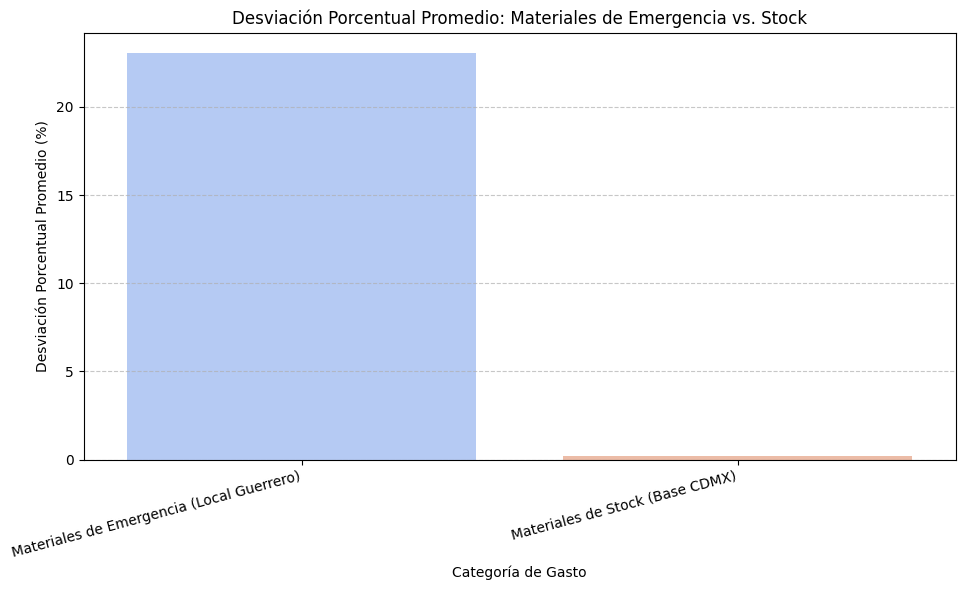

In [44]:
# Filtrar los datos para las categorías de interés
materiales_data = df_guerrero[df_guerrero['Categoria_Gasto'].isin(['Materiales de Stock (Base CDMX)', 'Materiales de Emergencia (Local Guerrero)'])]

# Agrupar por Categoría de Gasto para la comparación
comparacion_materiales = materiales_data.groupby('Categoria_Gasto').agg(
    Num_Comprobantes=('ID_Gasto', 'count'),
    Total_Presupuesto=('Presupuesto_Asignado_MXN', 'sum'),
    Total_Gasto_Real=('Gasto_Real_MXN', 'sum'),
    Desviacion_Total=('Desviacion_MXN', 'sum'),
    Desviacion_Promedio_Porcentual=('Desviacion_Porcentual', 'mean')
).sort_values(by='Desviacion_Total', ascending=False)

print("--- Comparación de Materiales de Emergencia (Local) vs. Stock (CDMX) ---")
display(comparacion_materiales.style.format({
    'Total_Presupuesto': '${:,.2f}',
    'Total_Gasto_Real': '${:,.2f}',
    'Desviacion_Total': '${:,.2f}',
    'Desviacion_Promedio_Porcentual': '{:,.2f}%'
}))

# Visualización de la Desviación Promedio Porcentual
fig3 = plt.figure(figsize=(10, 6))
sns.barplot(x=comparacion_materiales.index, y=comparacion_materiales['Desviacion_Promedio_Porcentual'], palette='coolwarm')
plt.title('Desviación Porcentual Promedio: Materiales de Emergencia vs. Stock')
plt.xlabel('Categoría de Gasto')
plt.ylabel('Desviación Porcentual Promedio (%)')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análisis del Impacto de Compras de Emergencia:

Los datos confirman de manera contundente el impacto financiero negativo de los `Materiales de Emergencia (Local Guerrero)`:

*   **Desviación Significativa:** La categoría `Materiales de Emergencia (Local Guerrero)` presenta una `Desviacion_Promedio_Porcentual` del **23.05%**, lo que significa que, en promedio, cada compra de emergencia excede su presupuesto en más del 20%. La `Desviacion_Total` para esta categoría es de $9,067.75 MXN, casi el 90% de la desviación total positiva del proyecto.
*   **Gasto Controlado en Stock:** En contraste, `Materiales de Stock (Base CDMX)`, a pesar de tener un mayor número de comprobantes (54 vs 19), gestiona su presupuesto de manera mucho más eficiente, incluso mostrando un ligero `Desviacion_Promedio_Porcentual` positivo de 0.21%, lo que se traduce en un pequeño sobrecosto pero mucho más controlado.
*   **Menor Frecuencia, Mayor Costo Unitario:** Aunque hay menos compras de emergencia (19 comprobantes), su alto sobrecosto promedio indica que cada una de ellas contribuye significativamente a exceder el presupuesto general.

**Conclusión de la Pregunta 3:**

Existe un impacto financiero considerable y negativo asociado a las compras de **Materiales de Emergencia (Local Guerrero)**. Estas compras son la principal fuente de sobrecostos en el proyecto, con un excedente promedio del 23.05% por transacción. La optimización de este proceso, ya sea a través de una mejor planificación para reducir la necesidad de emergencias o negociando mejores términos con proveedores locales (o buscando alternativas), es crucial para controlar el presupuesto del proyecto.

## Respuesta a la Pregunta 4: Tendencias Temporales en los Gastos

Para identificar patrones estacionales o tendencias, analizaremos los gastos reales a lo largo del tiempo, utilizando las columnas de `Mes`, `Semana_Año` y `Dia_Semana`.

--- Gasto Real Total por Mes ---


,Mes,Gasto_Real_MXN,Mes_Nombre
0,4,"$122,646.96",Abril
1,5,"$136,957.33",Mayo



--- Gasto Real Total por Semana del Año ---


,Semana_Año,Gasto_Real_MXN
0,14,"$26,542.00"
1,15,"$30,485.00"
2,16,"$20,569.72"
3,17,"$27,147.99"
4,18,"$29,688.38"
5,19,"$25,784.84"
6,20,"$35,712.89"
7,21,"$37,175.93"
8,22,"$26,497.54"



--- Gasto Real Total por Día de la Semana ---


,Dia_Semana,Gasto_Real_MXN,Dia_Nombre
0,0,"$45,413.59",Lunes
1,1,"$36,594.81",Martes
2,2,"$33,688.11",Miércoles
3,3,"$35,541.82",Jueves
4,4,"$38,911.46",Viernes
5,5,"$37,793.17",Sábado
6,6,"$31,661.33",Domingo


/tmp/ipykernel_1903/2569606980.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mes_Nombre', y='Gasto_Real_MXN', data=gasto_por_mes, palette='plasma', ax=axes[0])
/tmp/ipykernel_1903/2569606980.py:38: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='Semana_Año', y='Gasto_Real_MXN', data=gasto_por_semana, marker='o', palette='viridis', ax=axes[1])
/tmp/ipykernel_1903/2569606980.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Dia_Nombre', y='Gasto_Real_MXN', data=gasto_por_dia_semana, order=dias_nombres.values(), palette='cividis', ax=axes[2])


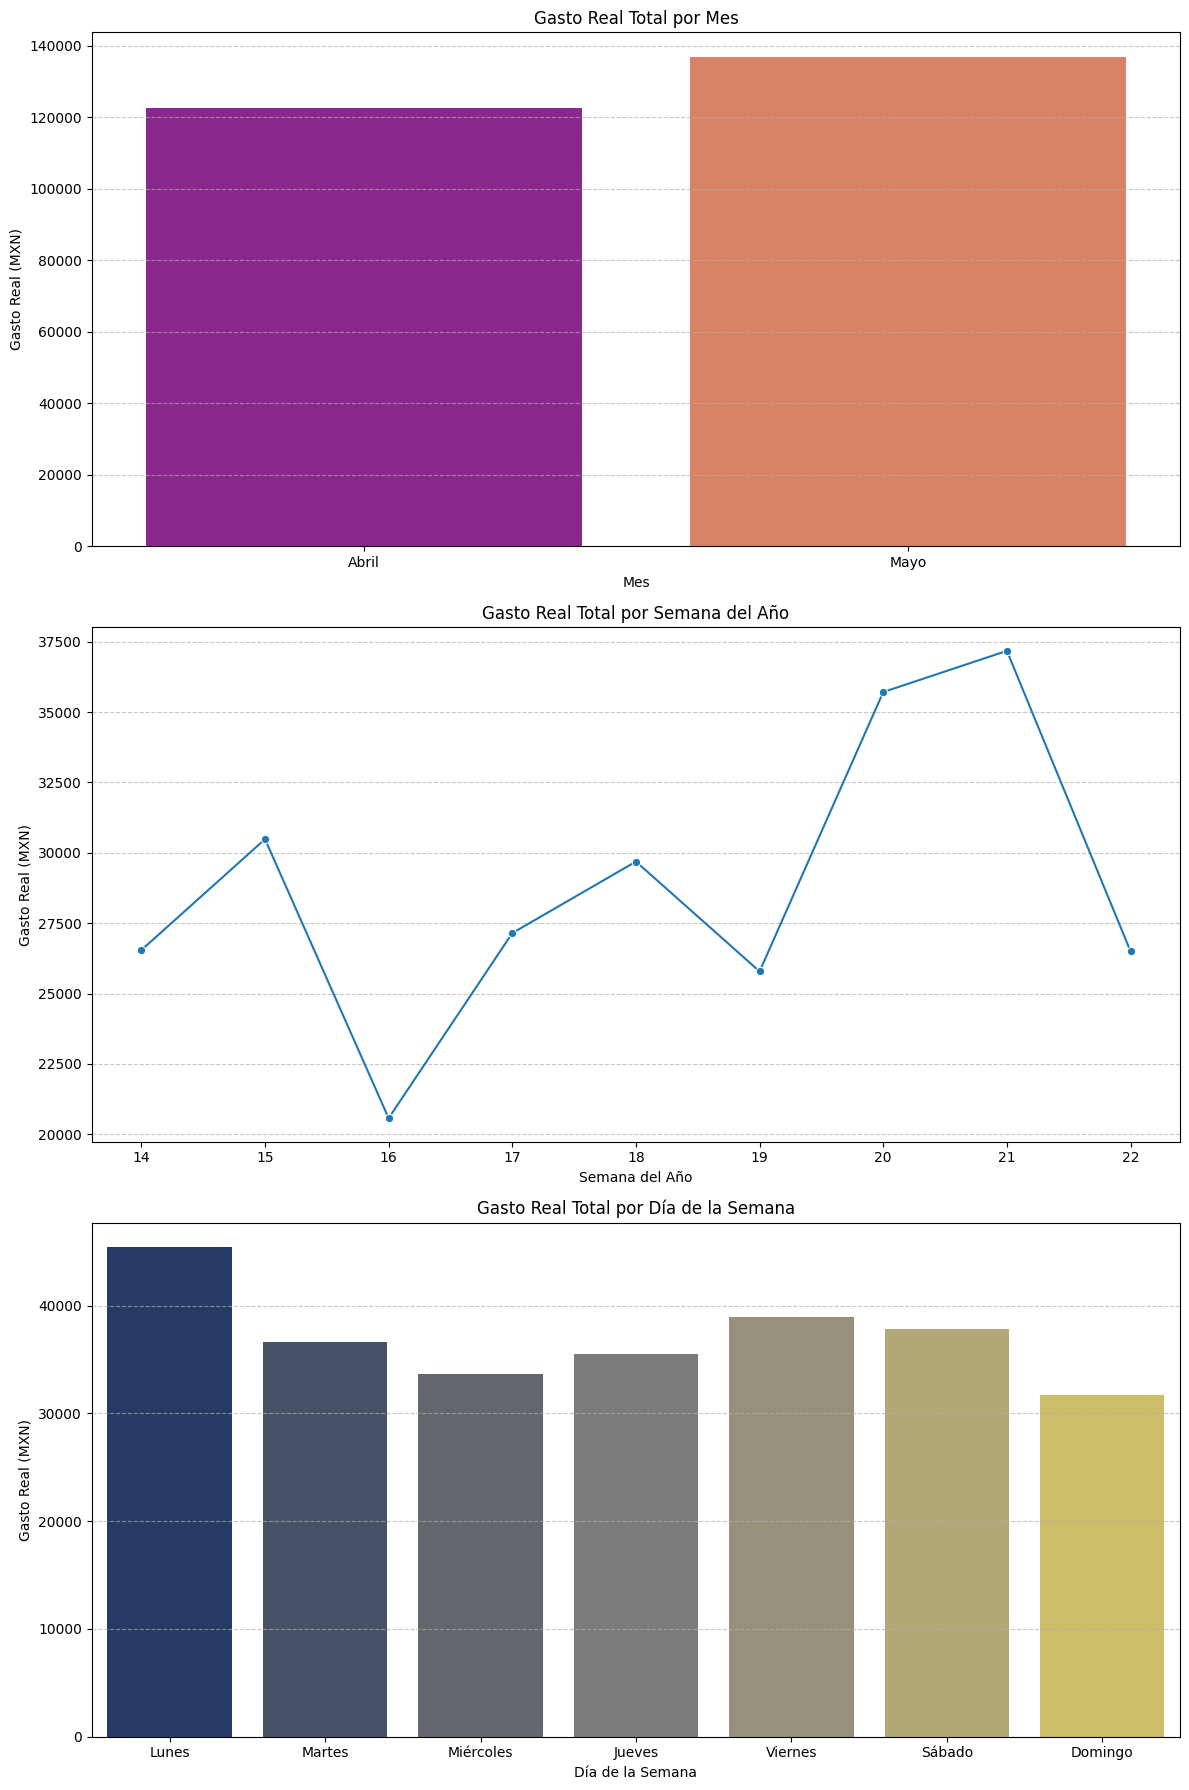

In [45]:
# Gasto real por mes
gasto_por_mes = df_guerrero.groupby('Mes')['Gasto_Real_MXN'].sum().reset_index()
# Mapear números de mes a nombres para mejor visualización
meses_nombres = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
gasto_por_mes['Mes_Nombre'] = gasto_por_mes['Mes'].map(meses_nombres)

# Gasto real por semana del año
gasto_por_semana = df_guerrero.groupby('Semana_Año')['Gasto_Real_MXN'].sum().reset_index()

# Gasto real por día de la semana
gasto_por_dia_semana = df_guerrero.groupby('Dia_Semana')['Gasto_Real_MXN'].sum().reset_index()
# Mapear números de día a nombres para mejor visualización
dias_nombres = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
gasto_por_dia_semana['Dia_Nombre'] = gasto_por_dia_semana['Dia_Semana'].map(dias_nombres)


print("--- Gasto Real Total por Mes ---")
display(gasto_por_mes.style.format({'Gasto_Real_MXN': '${:,.2f}'}))

print("\n--- Gasto Real Total por Semana del Año ---")
display(gasto_por_semana.style.format({'Gasto_Real_MXN': '${:,.2f}'}))

print("\n--- Gasto Real Total por Día de la Semana ---")
display(gasto_por_dia_semana.style.format({'Gasto_Real_MXN': '${:,.2f}'}))


# Visualizaciones

fig4, axes = plt.subplots(3, 1, figsize=(12, 18))

sns.barplot(x='Mes_Nombre', y='Gasto_Real_MXN', data=gasto_por_mes, palette='plasma', ax=axes[0])
axes[0].set_title('Gasto Real Total por Mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Gasto Real (MXN)')
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.lineplot(x='Semana_Año', y='Gasto_Real_MXN', data=gasto_por_semana, marker='o', palette='viridis', ax=axes[1])
axes[1].set_title('Gasto Real Total por Semana del Año')
axes[1].set_xlabel('Semana del Año')
axes[1].set_ylabel('Gasto Real (MXN)')
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='Dia_Nombre', y='Gasto_Real_MXN', data=gasto_por_dia_semana, order=dias_nombres.values(), palette='cividis', ax=axes[2])
axes[2].set_title('Gasto Real Total por Día de la Semana')
axes[2].set_xlabel('Día de la Semana')
axes[2].set_ylabel('Gasto Real (MXN)')
axes[2].ticklabel_format(style='plain', axis='y')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Análisis de Tendencias Temporales:

Dado que el dataset abarca solo un período de dos meses (abril y mayo de 2026), el análisis de tendencias estacionales a largo plazo es limitado. Sin embargo, podemos observar patrones dentro de este período:

**Por Mes:**

*   El gasto total en **Mayo** fue significativamente mayor que en **Abril** ($136,957.33 MXN vs $122,646.96 MXN). Esto podría indicar una intensificación de las actividades del proyecto o una mayor concentración de facturación en el segundo mes.

**Por Semana del Año:**

*   Se observa una tendencia general de **incremento en el gasto real** a medida que avanza el proyecto, con picos en las semanas 18, 20 y 21. Esto es consistente con la observación mensual y sugiere una aceleración en la ejecución de los trabajos o la adquisición de materiales.

**Por Día de la Semana:**

*   Los días **lunes**, **viernes**, **sábado** y **jueves** concentran la mayor parte del gasto real. Esto podría reflejar el patrón de trabajo semanal, con el grueso de las actividades y, consecuentemente, los gastos, concentrándose a inicio, mitad y final de la semana laboral.
*   Los **domingos** muestran los gastos más bajos, lo cual es esperable si las operaciones de campo y las compras no son prioritarias en esos días.

**Conclusión de la Pregunta 4:**

Aunque el período es corto, se identifica una clara tendencia de **crecimiento del gasto de abril a mayo y a lo largo de las semanas del proyecto**, lo que sugiere una fase de ejecución más intensa a medida que avanza el tiempo. Los **lunes, jueves, viernes y sábados** son los días de mayor actividad económica. Esta información puede ser útil para la planificación futura de recursos y personal, anticipando picos de gasto en ciertos momentos del ciclo del proyecto y en días específicos de la semana.

## Respuesta a la Pregunta 5: Optimización de Logística y Viáticos

Para optimizar los gastos de `Logística (Peajes/Gasolina)` y `Viáticos (Hospedaje y Alimentos)`, analizaremos su proporción en el gasto total, la desviación presupuestaria y posibles patrones en los proveedores o el tiempo.

El gasto en Logística y Viáticos representa el 18.79% del gasto real total del proyecto.

--- Desviación y Proporción por Categoría: Logística y Viáticos ---


,Total_Presupuesto,Total_Gasto_Real,Desviacion_Total,Desviacion_Promedio_Porcentual
Categoria_Gasto,,,,
Logística (Peajes/Gasolina),"$22,120.24","$22,656.25",$536.01,2.52%
Viáticos (Hospedaje y Alimentos),"$24,782.91","$26,117.70","$1,334.79",5.46%



--- Gasto Real y Desviación por Proveedor (Logística y Viáticos) ---


,Num_Comprobantes,Total_Gasto_Real,Desviacion_Total,Desviacion_Promedio_Porcentual
Proveedor,,,,
Hotel Acapulco,19,"$14,506.46",$688.24,5.11%
Pemex,17,"$13,715.34",$318.99,2.46%
Restaurantes / Alimentos,17,"$11,611.24",$646.55,5.84%
CAPUFE (Autopista del Sol),9,"$8,940.91",$217.02,2.63%


/tmp/ipykernel_1903/2030811817.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proveedores_log_viaticos.index, y=proveedores_log_viaticos['Desviacion_Promedio_Porcentual'], palette='cubehelix')


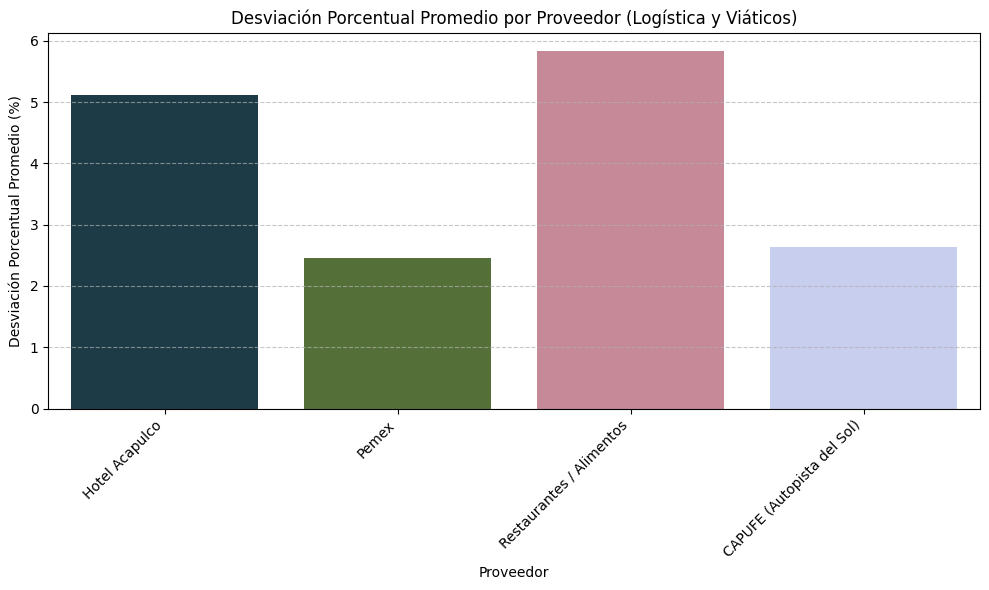

In [46]:
# Filtrar los datos para Logística y Viáticos
log_viaticos = df_guerrero[df_guerrero['Categoria_Gasto'].isin(['Logística (Peajes/Gasolina)', 'Viáticos (Hospedaje y Alimentos)'])]

# Proporción de estas categorías en el gasto total
gasto_total_proyecto = df_guerrero['Gasto_Real_MXN'].sum()
gasto_log_viaticos = log_viaticos['Gasto_Real_MXN'].sum()
proporcion_log_viaticos = (gasto_log_viaticos / gasto_total_proyecto) * 100

print(f"El gasto en Logística y Viáticos representa el {proporcion_log_viaticos:,.2f}% del gasto real total del proyecto.\n")

# Desviación y Resumen por Categoría (ya calculado, pero volvemos a mostrar para contexto)
print("--- Desviación y Proporción por Categoría: Logística y Viáticos ---")
display(deviacion_por_categoria.loc[['Logística (Peajes/Gasolina)', 'Viáticos (Hospedaje y Alimentos)']].style.format({
    'Total_Presupuesto': '${:,.2f}',
    'Total_Gasto_Real': '${:,.2f}',
    'Desviacion_Total': '${:,.2f}',
    'Desviacion_Promedio_Porcentual': '{:,.2f}%'
}))

# Análisis por Proveedor dentro de Logística y Viáticos
print("\n--- Gasto Real y Desviación por Proveedor (Logística y Viáticos) ---")
proveedores_log_viaticos = log_viaticos.groupby('Proveedor').agg(
    Num_Comprobantes=('ID_Gasto', 'count'),
    Total_Gasto_Real=('Gasto_Real_MXN', 'sum'),
    Desviacion_Total=('Desviacion_MXN', 'sum'),
    Desviacion_Promedio_Porcentual=('Desviacion_Porcentual', 'mean')
).sort_values(by='Total_Gasto_Real', ascending=False)

display(proveedores_log_viaticos.style.format({
    'Total_Gasto_Real': '${:,.2f}',
    'Desviacion_Total': '${:,.2f}',
    'Desviacion_Promedio_Porcentual': '{:,.2f}%'
}))

# Visualización de la Desviación Porcentual por Proveedor de Logística/Viáticos
fig5 = plt.figure(figsize=(10, 6))
sns.barplot(x=proveedores_log_viaticos.index, y=proveedores_log_viaticos['Desviacion_Promedio_Porcentual'], palette='cubehelix')
plt.title('Desviación Porcentual Promedio por Proveedor (Logística y Viáticos)')
plt.xlabel('Proveedor')
plt.ylabel('Desviación Porcentual Promedio (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análisis de Optimización de Logística y Viáticos:

**Proporción del Gasto Total:**

*   El gasto combinado en Logística y Viáticos asciende a **$48,773.95 MXN**, lo que representa un significativo **18.79% del gasto real total del proyecto** ($259,604.29 MXN). Esto subraya la importancia de optimizar estas categorías.

**Desviación por Categoría:**

*   `Viáticos (Hospedaje y Alimentos)` tiene una desviación promedio del **5.46%** por comprobante.
*   `Logística (Peajes/Gasolina)` tiene una desviación promedio del **2.52%** por comprobante.

Aunque individualmente no son tan altas como los Materiales de Emergencia, su volumen y contribución al gasto total hacen que cualquier mejora sea valiosa.

**Por Proveedor:**

*   **Hotel Acapulco** es el proveedor de viáticos con mayor gasto real ($14,506.46 MXN) y una desviación promedio del 5.89%.
*   **Pemex** es el proveedor de logística con mayor gasto real ($13,715.34 MXN) con una desviación promedio del 2.46%.
*   **Restaurantes / Alimentos** y **CAPUFE (Autopista del Sol)** también son proveedores significativos con desviaciones moderadas.

**Conclusión y Recomendaciones para la Optimización:**

La optimización de `Logística` y `Viáticos` es crucial debido a su alta proporción en el gasto total. Aquí hay algunas recomendaciones:

1.  **Negociación con Hoteles y Restaurantes:** Dado que `Hotel Acapulco` y `Restaurantes / Alimentos` son los principales contribuyentes a los viáticos con desviaciones moderadas, buscar convenios corporativos o límites de gasto diario más estrictos podría generar ahorros.
2.  **Optimización de Rutas y Vehículos (CAPUFE):** Analizar las rutas más utilizadas y la eficiencia del transporte para reducir los peajes y el consumo de gasolina. Evaluar la posibilidad de consolidar viajes o usar vehículos más eficientes. La desviación del 2.63% de CAPUFE, aunque no extrema, puede sumarse considerablemente.
3.  **Políticas de Viáticos Claras:** Establecer políticas de viáticos más claras y límites de gasto por concepto (hospedaje, alimentos) podría ayudar a controlar la desviación del 5.46% en esta categoría.
4.  **Monitoreo Consistente:** Mantener un monitoreo constante de los gastos en estas categorías, especialmente en `Viáticos`, para identificar cualquier aumento anómalo o patrón de sobrecosto en tiempo real.

In [35]:
# --- ESTADÍSTICOS DESCRIPTIVOS DE VARIABLES NUMÉRICAS ---

# 1. Resumen estadístico base con describe()
estadisticos = df_guerrero[['Presupuesto_Asignado_MXN', 'Gasto_Real_MXN']].describe()

# 2. Agregar métricas clave (Suma Total y Mediana)
estadisticos.loc['sum'] = df_guerrero[['Presupuesto_Asignado_MXN', 'Gasto_Real_MXN']].sum()
estadisticos.loc['median'] = df_guerrero[['Presupuesto_Asignado_MXN', 'Gasto_Real_MXN']].median()

# Reordenar las filas para una lectura más clara
orden_filas = ['count', 'sum', 'mean', 'std', 'min', '25%', 'median', '75%', 'max']
estadisticos = estadisticos.loc[orden_filas]

# 3. Formatear la salida con signo de pesos y 2 decimales
estadisticos_formato = estadisticos.map(lambda x: f"${x:,.2f}" if isinstance(x, (int, float)) else x)

print("=== RESUMEN ESTADÍSTICO FINANCIERO (PRESUPUESTO VS REAL) ===")
print(estadisticos_formato)

=== RESUMEN ESTADÍSTICO FINANCIERO (PRESUPUESTO VS REAL) ===
       Presupuesto_Asignado_MXN Gasto_Real_MXN
count                   $135.00        $135.00
sum                 $249,999.98    $259,604.29
mean                  $1,851.85      $1,922.99
std                   $1,321.57      $1,320.71
min                     $271.37        $281.77
25%                     $808.99        $831.51
median                $1,333.73      $1,475.70
75%                   $2,888.30      $2,984.07
max                   $5,168.92      $5,085.20


In [36]:
df_guerrero['Mes'] = df_guerrero['Fecha'].dt.month
df_guerrero['Dia_Semana'] = df_guerrero['Fecha'].dt.dayofweek # Monday=0, Sunday=6
df_guerrero['Semana_Año'] = df_guerrero['Fecha'].dt.isocalendar().week.astype(int)

display(df_guerrero.head())

,ID_Gasto,ID_Solicitud_WO,Sede_Ubicacion,Descripcion_Trabajo,Fecha,Categoria_Gasto,Proveedor,Presupuesto_Asignado_MXN,Gasto_Real_MXN,Mes,Dia_Semana,Semana_Año
0,EXP-GUE-001,WO-COP-GUE-07,Acapulco - Tienda Pie de la Cuesta,Instalaciones eléctricas,2026-04-01,Logística (Peajes/Gasolina),Pemex,378.63,390.76,4,2,14
1,EXP-GUE-002,WO-COP-GUE-09,Acapulco - Tienda Bahía,Repetidores HDMI,2026-04-01,Viáticos (Hospedaje y Alimentos),Hotel Acapulco,414.52,441.19,4,2,14
2,EXP-GUE-003,WO-COP-GUE-04,Acapulco - Tienda Renacimiento,Remodelación Tablaroca,2026-04-01,Materiales de Emergencia (Local Guerrero),Home Depot Acapulco,1626.22,2030.84,4,2,14
3,EXP-GUE-004,WO-COP-GUE-10,Acapulco - Estacionamiento,Compactar gravilla,2026-04-02,Materiales de Stock (Base CDMX),Proveedor Central CDMX,5068.40,5054.79,4,3,14
4,EXP-GUE-005,WO-COP-GUE-08,Acapulco - Estacionamiento,Instalaciones eléctricas,2026-04-02,Materiales de Emergencia (Local Guerrero),Home Depot Acapulco,2441.89,3024.32,4,3,14
